# Step 1 : Load Data :

In [1]:
import pandas as pd

df = pd.read_csv("avocado.csv.csv")

print(df.shape)
print(df.columns.tolist())

(18249, 14)
['Unnamed: 0', 'Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year', 'region']


# Step 2 : Data Cleaning :

In [2]:
# Convert Date column to datetime :

df['Date']=pd.to_datetime(df['Date'])

# Remove unnecessary column :

df=df.drop(columns=['Unnamed: 0'])

# Check dataset information :

print(df.info())

# Check missing values :

print("\nMissing Values:")
print(df.isnull().sum())

# Display first five rows :

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          18249 non-null  datetime64[ns]
 1   AveragePrice  18249 non-null  float64       
 2   Total Volume  18249 non-null  float64       
 3   4046          18249 non-null  float64       
 4   4225          18249 non-null  float64       
 5   4770          18249 non-null  float64       
 6   Total Bags    18249 non-null  float64       
 7   Small Bags    18249 non-null  float64       
 8   Large Bags    18249 non-null  float64       
 9   XLarge Bags   18249 non-null  float64       
 10  type          18249 non-null  object        
 11  year          18249 non-null  int64         
 12  region        18249 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 1.8+ MB
None

Missing Values:
Date            0
AveragePrice    0
To

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


# Step 3 : Explore the Dataset :

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (18249, 13)

Columns:
Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='object')

Summary Statistics:
                                Date  AveragePrice  Total Volume  \
count                          18249  18249.000000  1.824900e+04   
mean   2016-08-13 23:30:43.498273792      1.405978  8.506440e+05   
min              2015-01-04 00:00:00      0.440000  8.456000e+01   
25%              2015-10-25 00:00:00      1.100000  1.083858e+04   
50%              2016-08-14 00:00:00      1.370000  1.073768e+05   
75%              2017-06-04 00:00:00      1.660000  4.329623e+05   
max              2018-03-25 00:00:00      3.250000  6.250565e+07   
std                              NaN      0.402677  3.453545e+06   

               4046          4225          4770    Total Bags    Small Bags  \
count  1.824900e+04  1.824900e+04  1.824900e+04  1.824900e+

# Step 4 : Average Price Trend Over Time :

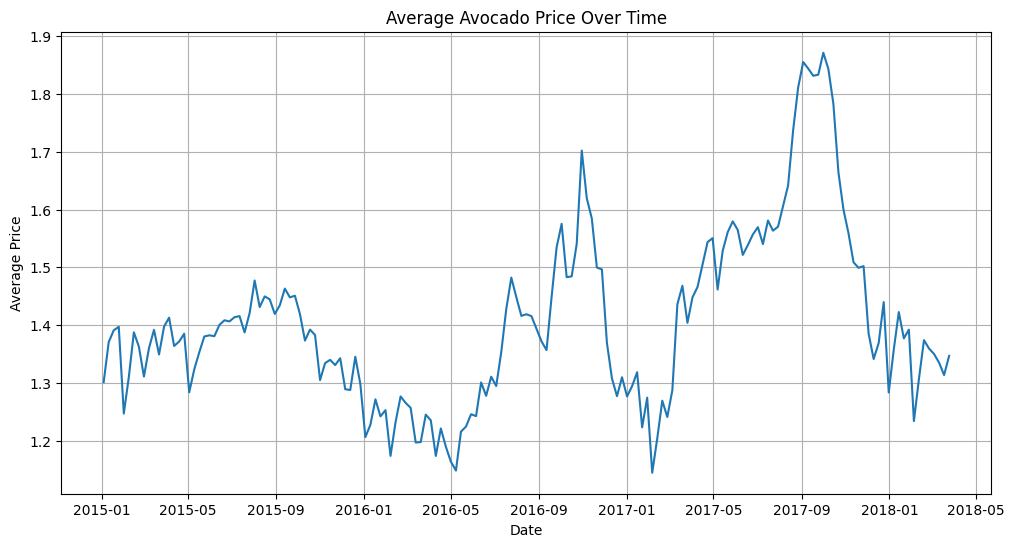

In [4]:
import matplotlib.pyplot as plt 

price_trend = df.groupby('Date')['AveragePrice'].mean()

plt.figure(figsize=(12,6))
plt.plot(price_trend)

plt.title("Average Avocado Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price")
plt.grid(True)

plt.savefig("avocado_prive_trend.png", bbox_inches="tight")

plt.show()

# Step 5 : Compare Prices by Avocado Type :

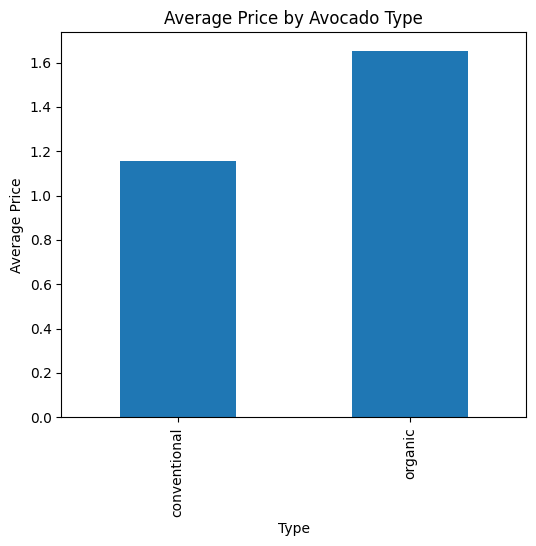

In [5]:
type_price = df.groupby('type')['AveragePrice'].mean()

plt.figure(figsize=(6,5))
type_price.plot(kind='bar')

plt.title("Average Price by Avocado Type")
plt.xlabel("Type")
plt.ylabel("Average Price")

plt.savefig("price_by_type.png",  bbox_inches="tight")

plt.show()

# Step 6 : Prepare Data for Machine Learning :

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select Features :
x=df[['Total Volume', '4046', '4225', '4770',
     'Total Bags', 'Small Bags',
     'Large Bags', 'XLarge Bags', 'year']]

# Target :
y=df['AveragePrice']

# Train-test split :
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

print("Training Data:", x_train.shape)
print("Testing Data:", x_test.shape)

Training Data: (14599, 9)
Testing Data: (3650, 9)


# Step 7 : Train the Model :

In [11]:
model = LinearRegression()

model.fit(x_train, y_train)

predictions = model.predict(x_test)

print("Model Training Completed")

Model Training Completed


# Step 8 : Evaluate the Model :

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

Mean Absolute Error: 0.31462326234935406
Mean Squared Error: 0.15366867305549572
R2 Score: 0.04357036287035854


# Step 9 : Actual vs Predicted Price Chart :

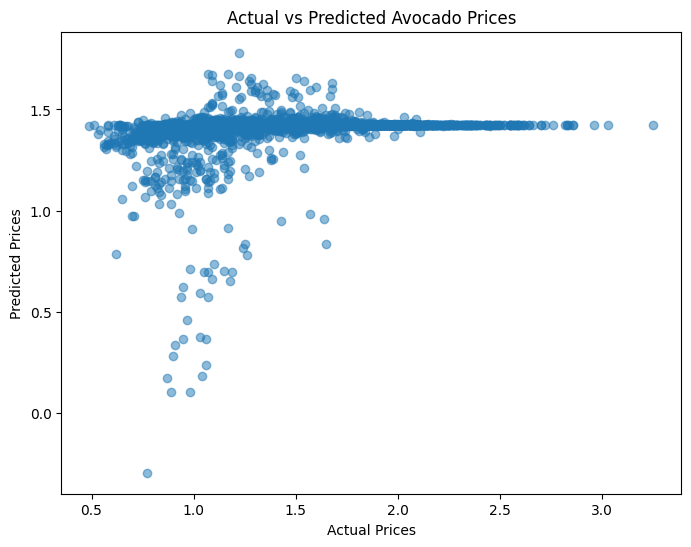

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Avocado Prices")

plt.savefig("actual_vs_predicted.png", bbox_inches="tight")

plt.show()

# Conclusion :

The avocado price prediction model was built using Linear Regression.

The model learned the relationship between avocado sales features and average prices.

Although the prediction accuracy is limited, the project demonstrates the complete machine learning workflow, including data cleaning, exploratory data analysis, model training, prediction, and evaluation.

More advanced machine learning models and additional features such as weather conditions, transportation costs, seasonal demand, and regional economic factors could improve prediction performance.